In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Define the path to the dataset and load it into a DataFrame using pandas
# This allows for easy manipulation and analysis of the data
dataset_path = "Housing_Price_Data.csv"
housing_data = pd.read_csv(dataset_path)

# Inspect the data structure
# Display the first 5 rows of the dataset to get a quick overview of the data
print("--- Data Head ---")
print(housing_data.head())

# Display information about the dataset
# This includes the number of rows and columns, column names, data types, and non-null counts
print("\n--- Data Info ---")
housing_data.info()

# Display statistical summaries of numerical columns in the dataset
# This includes count, mean, standard deviation, min, max, and percentiles
print("\n--- Statistical Summary ---")
print(housing_data.describe())


--- Data Head ---
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries,

In [91]:
# Step 2: Explore the Data
# 1. Basic Exploration
print("\n--- First Few Rows ---")
print(housing_data.head())

# Drop irrelevant columns (if any, like IDs)
# Assuming no IDs are present in this dataset; modify as needed
# housing_data.drop(columns=['ID'], inplace=True, errors='ignore')

# 2. Check Datatypes
# Identify numerical and categorical columns
numerical_cols = housing_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = housing_data.select_dtypes(include=['object']).columns.tolist()
##object datatype hold text datatype or mixed in pandas

print("\n--- Numerical Columns ---")
print(numerical_cols)

print("\n--- Categorical Columns ---")
print(categorical_cols)

# Convert categorical columns to 'category' datatype for memory efficiency
for col in categorical_cols:
    housing_data[col] = housing_data[col].astype('category') 
##This is particularly beneficial when you have columns with repeated values, such as a column with a list of cities or categories.

# 3. Categorical Column Analysis
print("\n--- Unique Categories in Categorical Columns ---")
for col in categorical_cols:
    print(f"{col}: {housing_data[col].nunique()} unique categories") ##t returns the number of distinct, unique values in the specified column or series.

# 4. Missing Values
# Check for missing values in each column
missing_values = housing_data.isnull().sum()
missing_percentage = (missing_values / len(housing_data)) * 100

print("\n--- Missing Values ---")
print(pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_percentage}))



--- First Few Rows ---
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

--- Numerical Columns ---
['price', 'area', 'bedrooms', 'bathrooms', 'stor

Dropped columns: []
Missing values in categorical columns filled with mode.


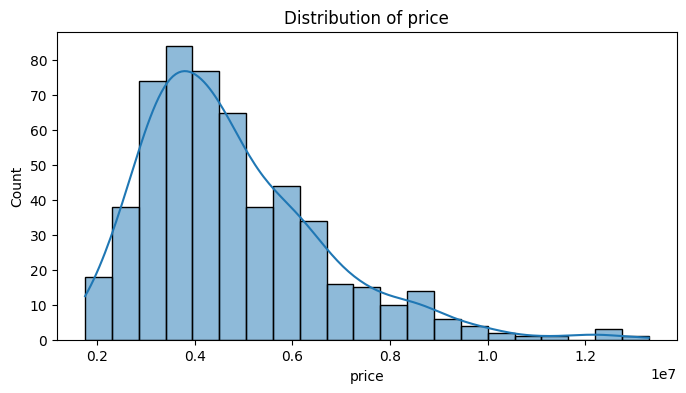

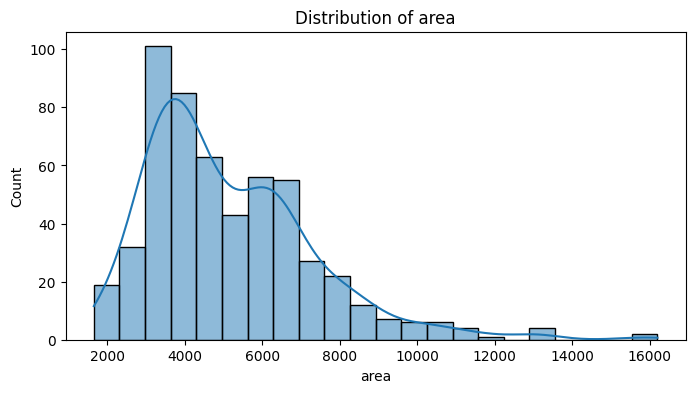

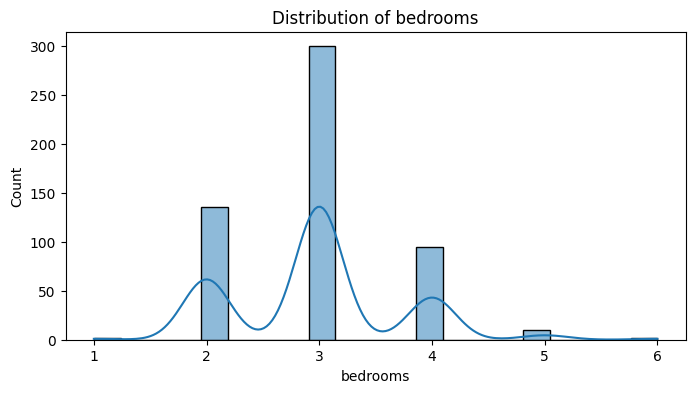

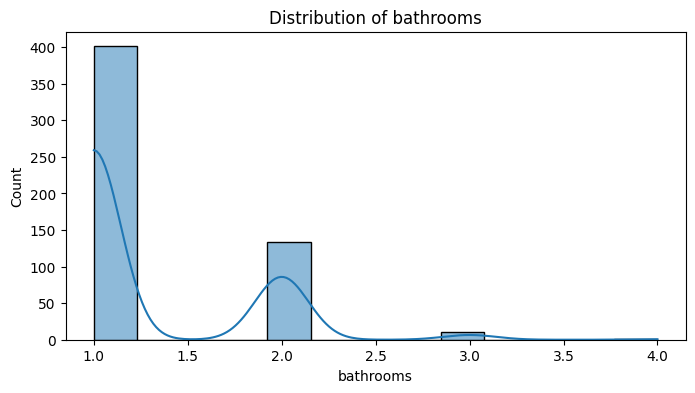

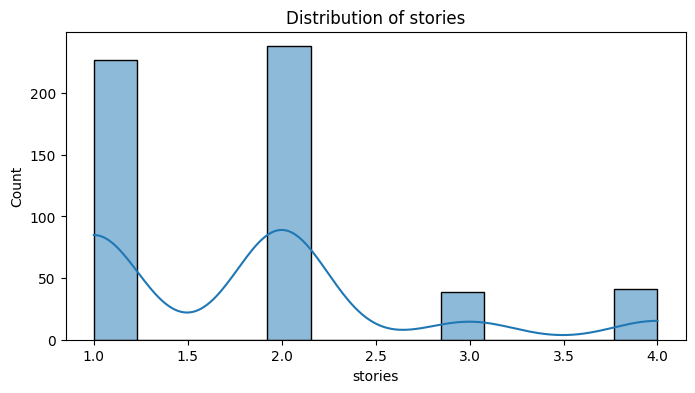

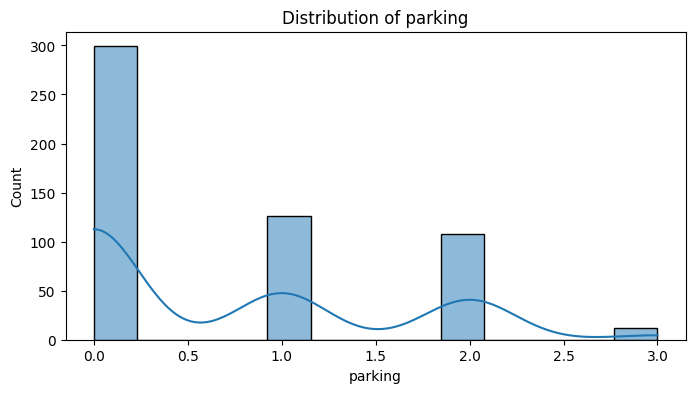

Skewness of numerical columns:
price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64
Missing values in numerical columns filled based on distribution.
Missing values after imputation:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [92]:
# Step 3: Handle Missing Values

# 1. Drop columns with high null ratios (>50%)
cols_to_drop = missing_percentage[missing_percentage > 50].index.tolist()
housing_data.drop(columns=cols_to_drop, inplace=True)
##inplace=True means the changes are made directly to the housing_data DataFrame (without needing to create a new one).
print(f"Dropped columns: {cols_to_drop}")

# 2. Handle missing values in categorical columns by filling with the mode
for col in categorical_cols:
    mode_value = housing_data[col].mode()[0]
    housing_data[col] = housing_data[col].fillna(mode_value)
print("Missing values in categorical columns filled with mode.")

# 3. Handle missing values in numerical columns based on distribution


# Visualize the distribution of numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(housing_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Check skewness of numerical columns
skewness = housing_data[numerical_cols].skew()
print(f"Skewness of numerical columns:\n{skewness}")

# Fill missing values based on skewness
# Handle missing values in numerical columns based on distribution
for col in numerical_cols:
    if skewness[col] > 1 or skewness[col] < -1:  # Highly skewed
        median_value = housing_data[col].median()
        housing_data[col] = housing_data[col].fillna(median_value)  # Avoid inplace=True
    else:  # Symmetric or lightly skewed
        mean_value = housing_data[col].mean()
        housing_data[col] = housing_data[col].fillna(mean_value)  # Avoid inplace=True
##Positive Skew (Right Skew): The distribution has a right tail (outliers on the higher end).
##Skewness value: > 0 (e.g., 1, 2, etc.).
##Negative Skew (Left Skew): The distribution has a left tail (outliers on the lower end).
##Skewness value: < 0 (e.g., -1, -2, etc.).
##Symmetric Distribution: The distribution is balanced with no skew.
##Skewness value: ≈ 0 (close to zero).
print("Missing values in numerical columns filled based on distribution.")


# 4. Recheck for any missing values
missing_values_after = housing_data.isnull().sum()
print(f"Missing values after imputation:\n{missing_values_after}")


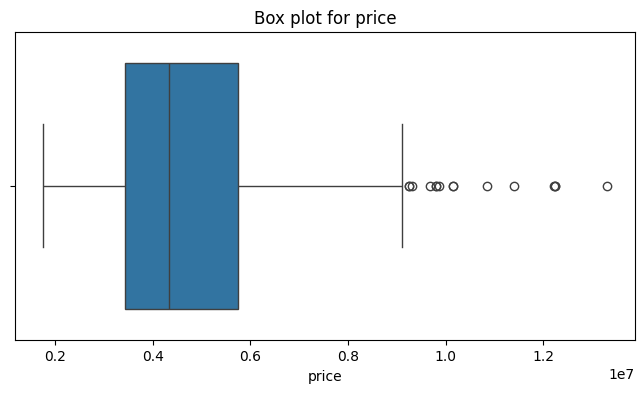

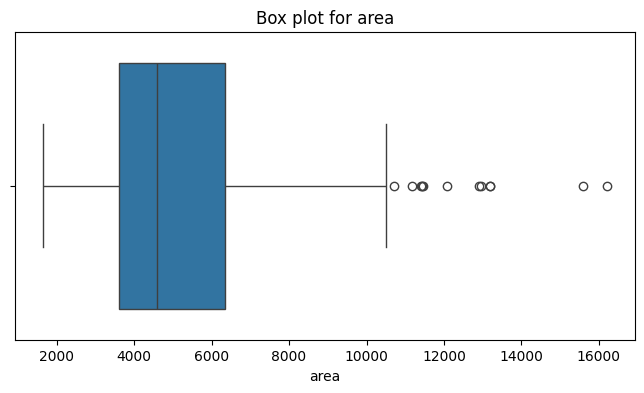

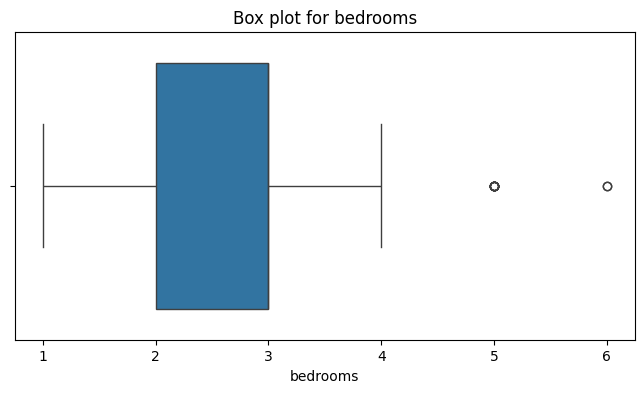

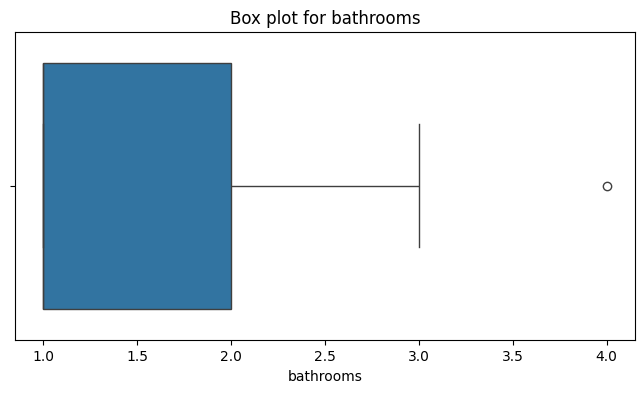

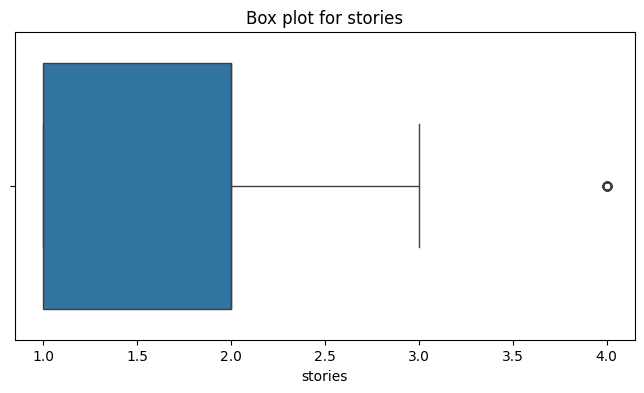

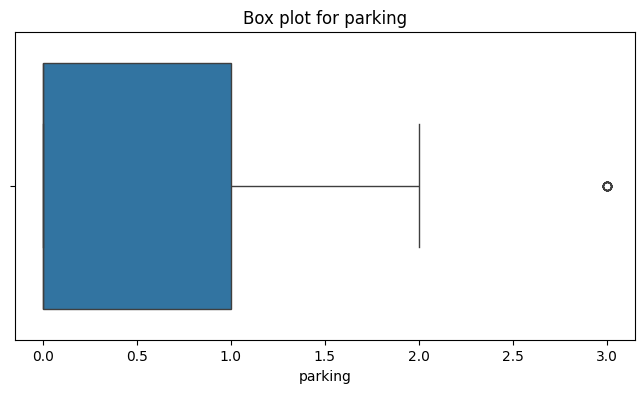

Outliers capped based on IQR method.
Rare categories in categorical columns replaced with mode.
Missing values after outlier treatment:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [93]:
# Step 1: Visualize Outliers using Box Plots
# Visualize outliers in numerical columns using box plots
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=housing_data[col])
    plt.title(f"Box plot for {col}")
    plt.show()

# Step 2: Capping Outliers (Winsorizing)
# Capping outliers in numerical columns
for col in numerical_cols:
    # Calculate the IQR (Interquartile Range)
    Q1 = housing_data[col].quantile(0.25)
    Q3 = housing_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping the values to the upper and lower bounds
    housing_data[col] = housing_data[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped based on IQR method.")

# Step 3: Handling Categorical Outliers
# Handle categorical outliers by replacing rare categories with the mode
for col in categorical_cols:
    # Calculate the frequency of categories
    category_counts = housing_data[col].value_counts()
    
    # Define a threshold for low frequency categories (e.g., appearing less than 5 times)
    rare_categories = category_counts[category_counts < 5].index.tolist()
    
    # Replace rare categories with the mode
    mode_value = housing_data[col].mode()[0]
    housing_data[col] = housing_data[col].replace(rare_categories, mode_value)

print("Rare categories in categorical columns replaced with mode.")

# Step 4: Recheck for any missing values after outlier treatment
missing_values_after_outliers = housing_data.isnull().sum()
print(f"Missing values after outlier treatment:\n{missing_values_after_outliers}")


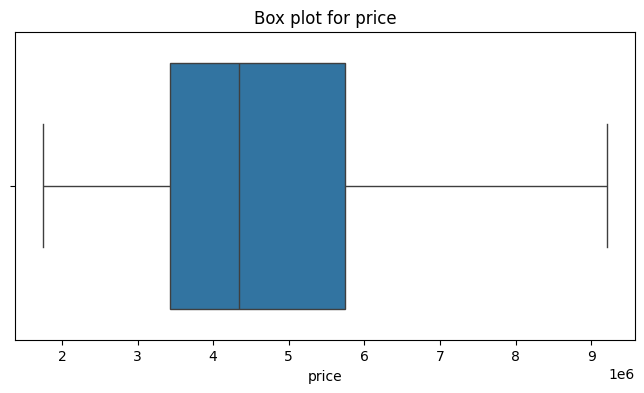

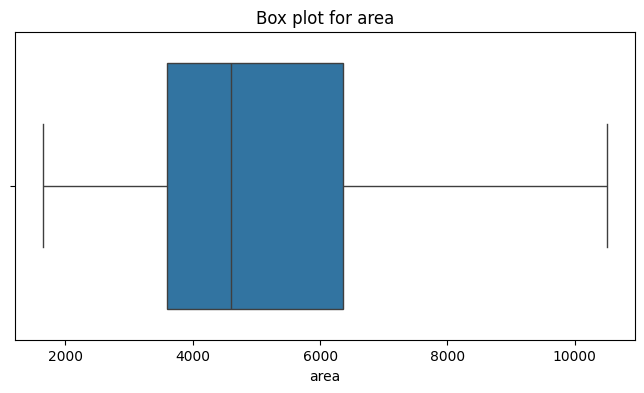

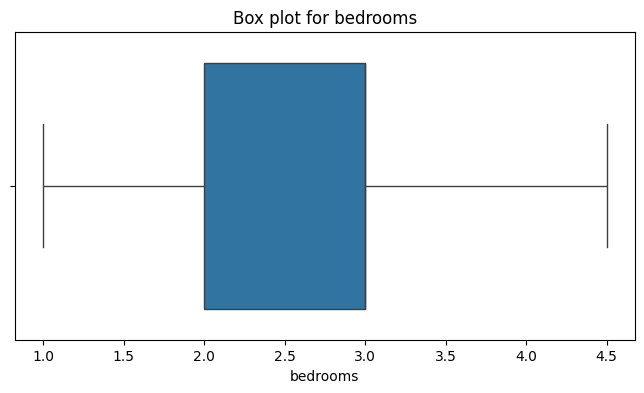

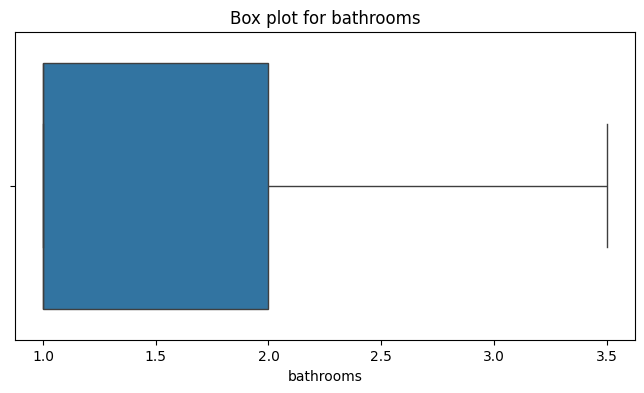

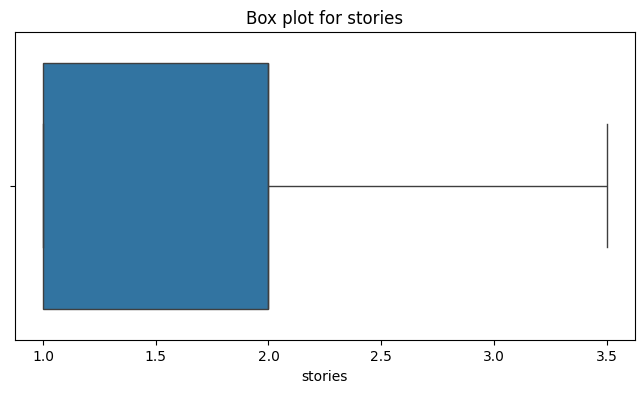

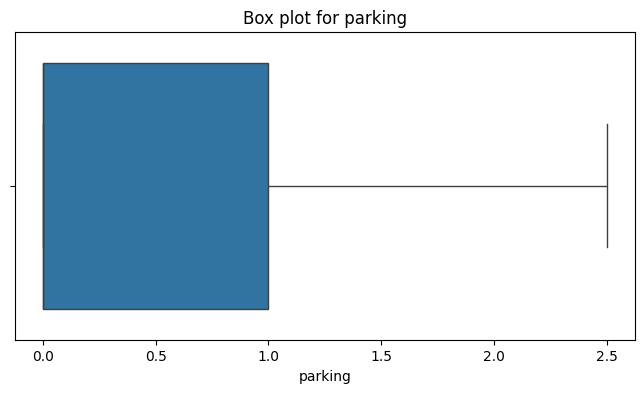

In [94]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=housing_data[col])
    plt.title(f"Box plot for {col}")
    plt.show()


In [95]:
#step5
# Check for duplicates and remove them
duplicates_before = housing_data.duplicated().sum()  # Count the number of duplicate rows before removal
print(f"Number of duplicate rows before removal: {duplicates_before}")

# Remove duplicates
housing_data.drop_duplicates(inplace=True)

# Check again for duplicates after removal
duplicates_after = housing_data.duplicated().sum()  # Count the number of duplicate rows after removal
print(f"Number of duplicate rows after removal: {duplicates_after}")


Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


In [96]:
#Step 6 :
# Step 1: Calculate the standard deviation of each numerical column
variance = housing_data[numerical_cols].std()
print(variance)
# Step 2: Define a threshold for low variance (e.g., variance close to 0)
low_variance_cols = variance[variance < 0.001].index.tolist()  # You can adjust the threshold based on your dataset

# Step 3: Drop low-variance columns
housing_data.drop(columns=low_variance_cols, inplace=True)

# Step 4: Print the dropped columns
print(f"Dropped low-variance columns: {low_variance_cols}")


price        1.745227e+06
area         2.005804e+03
bedrooms     6.975039e-01
bathrooms    4.979417e-01
stories      7.775434e-01
parking      8.347732e-01
dtype: float64
Dropped low-variance columns: []


In [97]:
#Step 7 : 
# Step 1: Define the label column (target variable)
label_column = 'price'  # Replace with the name of the target column

# Step 2: Separate the features (X) and the label (y)
X = housing_data.drop(columns=[label_column])  # Drop the label column to get features
y = housing_data[label_column]  # The label is the target column

# Step 3: Print the shapes of X and y to confirm separation
print(f"Features (X) shape: {X.shape}")
print(f"Label (y) shape: {y.shape}")


Features (X) shape: (545, 12)
Label (y) shape: (545,)


In [98]:
#Step 8:
# Importing necessary libraries
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce
import pandas as pd
# Create an instance of LabelEncoder
label_encoder = LabelEncoder()


# method 1: Ordinal Data (Label Encoding)(0,1,2,...)


# Check if 'mainroad' column exists in the dataset, and then apply label encoding
#print(housing_data['mainroad'].unique())

# method 2: High-Cardinality Columns (Binary Encoding or Frequency Encoding)

# Binary Encoding Example
# Check if 'prefarea' exists in the dataset and apply binary encoding
from sklearn.preprocessing import LabelEncoder

# List of columns to encode if they exist in the dataset
columns_to_encode = [
    'prefarea', 'mainroad', 'guestroom', 
    'basement', 'airconditioning', 'hotwaterheating'
]

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Iterate over the columns and apply label encoding if they exist
for col in columns_to_encode:
    if col in housing_data.columns:
        housing_data[col] = label_encoder.fit_transform(housing_data[col])
        print(f"Column '{col}' encoded using Label Encoding.")

# Check if 'furnishingstatus' exists in the dataset and apply binary encoding
if 'furnishingstatus' in housing_data.columns:
    housing_data = pd.get_dummies(housing_data, columns=['furnishingstatus'])
    print("High-cardinality column 'furnishingstatus' encoded using One-Hot Encoding.")


# Final dataset with encoded categorical columns
print("Final dataset after encoding:\n", housing_data.head(10))


# Model Building
#Building model
# Import the necessary library
from sklearn.model_selection import train_test_split

# Step 1: Define your feature set (X) and target variable (y)
# Assuming 'Price' is the target variable and all other columns are features

# X = features (all columns except 'Price')
X = housing_data.drop(columns=['price'])

# y = target variable (Price)
y = housing_data['price']

# Step 2: Split the data into training and testing sets
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the sizes of the train and test datasets
print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")




Column 'prefarea' encoded using Label Encoding.
Column 'mainroad' encoded using Label Encoding.
Column 'guestroom' encoded using Label Encoding.
Column 'basement' encoded using Label Encoding.
Column 'airconditioning' encoded using Label Encoding.
Column 'hotwaterheating' encoded using Label Encoding.
High-cardinality column 'furnishingstatus' encoded using One-Hot Encoding.
Final dataset after encoding:
      price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  9205000   7420       4.0        2.0      3.0         1          0   
1  9205000   8960       4.0        3.5      3.5         1          0   
2  9205000   9960       3.0        2.0      2.0         1          0   
3  9205000   7500       4.0        2.0      2.0         1          0   
4  9205000   7420       4.0        1.0      2.0         1          1   
5  9205000   7500       3.0        3.0      1.0         1          0   
6  9205000   8580       4.0        3.0      3.5         1          0   
7  9205000  105

In [99]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
mod = lin_reg.fit(X_train, y_train)
print("Linear Regression Model trained.")

Linear Regression Model trained.


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predicting the test set
y_pred = lin_reg.predict(X_test)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")


Mean Absolute Error (MAE): 880919.51
Mean Squared Error (MSE): 1286637069521.38
Root Mean Squared Error (RMSE): 1134300.26
R-squared: 0.68


In [101]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# User input for prediction
area = float(input("Enter the area in square feet: "))
bedrooms = int(input("Enter the number of bedrooms: "))
bathrooms = int(input("Enter the number of bathrooms: "))
furnishing_status = input("Enter the furnishing status (e.g., 'furnished' or 'unfurnished'): ")
stories = int(input("Enter the number of stories: "))
prefarea = input("Enter the preference for area (e.g., 'yes' or 'no'): ")
mainroad = input("Enter if the property is near the main road (e.g., 'yes' or 'no'): ")
guestroom = input("Enter if there is a guestroom (e.g., 'yes' or 'no'): ")
basement = input("Enter if the property has a basement (e.g., 'yes' or 'no'): ")
airconditioning = input("Enter if the property has air conditioning (e.g., 'yes' or 'no'): ")
hotwaterheating = input("Enter if the property has hot water heating (e.g., 'yes' or 'no'): ")

# Convert the user input into a dictionary
sample_data = {
    'area': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'furnishing_status': furnishing_status,
    'stories': stories,
    'prefarea': prefarea,
    'mainroad': mainroad,
    'guestroom': guestroom,
    'basement': basement,
    'airconditioning': airconditioning,
    'hotwaterheating': hotwaterheating
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample_data])

# List of categorical columns to be label encoded (except 'furnishing_status')
categorical_columns = [
    'prefarea', 'mainroad', 'guestroom', 'basement', 
    'airconditioning', 'hotwaterheating'
]

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Loop through each column and apply label encoding if it exists in the sample data
for col in categorical_columns:
    if col in sample_df.columns:
        sample_df[col] = label_encoder.fit_transform(sample_df[col])
       

# Apply One-Hot Encoding to 'furnishing_status' column
if 'furnishing_status' in sample_df.columns:
    sample_df = pd.get_dummies(sample_df, columns=['furnishing_status'], drop_first=True)
   

# Ensure the sample data matches the feature columns of the trained model (X_train)
sample_df = sample_df.reindex(columns=X_train.columns, fill_value=0)

# Predict the price using the trained model
predicted_price = mod.predict(sample_df)
formatted_price = round(predicted_price[0], 2)

# Display the predicted price
print("Predicted Price for the provided input:", formatted_price, "$")


Enter the area in square feet:  1500
Enter the number of bedrooms:  2
Enter the number of bathrooms:  3
Enter the furnishing status (e.g., 'furnished' or 'unfurnished'):  furnished
Enter the number of stories:  22
Enter the preference for area (e.g., 'yes' or 'no'):  yes
Enter if the property is near the main road (e.g., 'yes' or 'no'):  no
Enter if there is a guestroom (e.g., 'yes' or 'no'):  yes
Enter if the property has a basement (e.g., 'yes' or 'no'):  no
Enter if the property has air conditioning (e.g., 'yes' or 'no'):  yes
Enter if the property has hot water heating (e.g., 'yes' or 'no'):  no


Predicted Price for the provided input: 13197074.99 $


In [102]:
#Mean Absolute Error (MAE): The average of the absolute differences between predicted and true values.
#Mean Squared Error (MSE): The average of the squared differences between predicted and true values.
#Root Mean Squared Error (RMSE): The square root of MSE, which expresses error in the same units as the target variable.
#R-squared (R²) Score: Measures how well the model explains the variance in the data (ranges from -∞ to 1).

In [103]:
import tkinter as tk
from tkinter import messagebox
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Function to predict the price
def predict_price():
    # Get user inputs
    area = float(entry_area.get())
    bedrooms = int(entry_bedrooms.get())
    bathrooms = int(entry_bathrooms.get())
    furnishing_status = entry_furnishing_status.get()
    stories = int(entry_stories.get())  # Get 'stories' input
    prefarea = entry_prefarea.get()
    mainroad = entry_mainroad.get()
    guestroom = entry_guestroom.get()
    basement = entry_basement.get()
    airconditioning = entry_airconditioning.get()
    hotwaterheating = entry_hotwaterheating.get()

    # Create a dictionary from user input
    sample_data = {
        'area': area,
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'furnishing_status': furnishing_status,
        'stories': stories,
        'prefarea': prefarea,
        'mainroad': mainroad,
        'guestroom': guestroom,
        'basement': basement,
        'airconditioning': airconditioning,
        'hotwaterheating': hotwaterheating
    }

    # Convert to DataFrame
    sample_df = pd.DataFrame([sample_data])

    # List of categorical columns to be label encoded (except 'furnishing_status')
    categorical_columns = [
        'prefarea', 'mainroad', 'guestroom', 'basement', 
        'airconditioning', 'hotwaterheating'
    ]

    # Loop through each column and apply label encoding if it exists in the sample data
    for col in categorical_columns:
        if col in sample_df.columns:
            sample_df[col] = label_encoder.fit_transform(sample_df[col])

    # Apply One-Hot Encoding to 'furnishing_status' column
    if 'furnishing_status' in sample_df.columns:
        sample_df = pd.get_dummies(sample_df, columns=['furnishing_status'], drop_first=True)

    # Ensure the sample data matches the feature columns of the trained model (X_train)
    sample_df = sample_df.reindex(columns=X_train.columns, fill_value=0)

    # Predict the price using the trained model
    predicted_price = mod.predict(sample_df)
    formatted_price = round(predicted_price[0], 2)

    # Show the result
    messagebox.showinfo("Prediction", f"Predicted Price for the provided input: {formatted_price}$")

# Set up the GUI
root = tk.Tk()
root.title("House Price Prediction")

# Create input fields and labels
tk.Label(root, text="Area (sq ft):").grid(row=0, column=0, sticky="w")
entry_area = tk.Entry(root)
entry_area.grid(row=0, column=1)

tk.Label(root, text="Bedrooms:").grid(row=1, column=0, sticky="w")
entry_bedrooms = tk.Entry(root)
entry_bedrooms.grid(row=1, column=1)

tk.Label(root, text="Bathrooms:").grid(row=2, column=0, sticky="w")
entry_bathrooms = tk.Entry(root)
entry_bathrooms.grid(row=2, column=1)

tk.Label(root, text="Furnishing Status (furnished/unfurnished):").grid(row=3, column=0, sticky="w")
entry_furnishing_status = tk.Entry(root)
entry_furnishing_status.grid(row=3, column=1)

tk.Label(root, text="Stories:").grid(row=4, column=0, sticky="w")
entry_stories = tk.Entry(root)  # Changed variable name from entry_bathrooms to entry_stories
entry_stories.grid(row=4, column=1)

tk.Label(root, text="Prefarea (yes/no):").grid(row=5, column=0, sticky="w")
entry_prefarea = tk.Entry(root)
entry_prefarea.grid(row=5, column=1)

tk.Label(root, text="Mainroad (yes/no):").grid(row=6, column=0, sticky="w")
entry_mainroad = tk.Entry(root)
entry_mainroad.grid(row=6, column=1)

tk.Label(root, text="Guestroom (yes/no):").grid(row=7, column=0, sticky="w")
entry_guestroom = tk.Entry(root)
entry_guestroom.grid(row=7, column=1)

tk.Label(root, text="Basement (yes/no):").grid(row=8, column=0, sticky="w")
entry_basement = tk.Entry(root)
entry_basement.grid(row=8, column=1)

tk.Label(root, text="Air Conditioning (yes/no):").grid(row=9, column=0, sticky="w")
entry_airconditioning = tk.Entry(root)
entry_airconditioning.grid(row=9, column=1)

tk.Label(root, text="Hotwater Heating (yes/no):").grid(row=10, column=0, sticky="w")
entry_hotwaterheating = tk.Entry(root)
entry_hotwaterheating.grid(row=10, column=1)

# Button to make prediction
predict_button = tk.Button(root, text="Predict Price", command=predict_price)
predict_button.grid(row=11, column=0, columnspan=2)

# Run the GUI
root.mainloop()


In [66]:
pip install category_encoders


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 2.2 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.8 MB 2.4 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.8 MB 2.3 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.8 MB 2.4 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/9.8 MB 2.4 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.8 MB 2.5 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.8 MB 2.7 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.8 MB 2.8 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.8 MB 2.9 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.8 MB 3.0 MB/s eta 0:00:02
   ----------------------------- ---------- 7.3/9.8 MB 3.1 MB/s eta 0:00:01
   ----------------------